## Load DATA

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [8]:
columns = ['age','sex','cp','trestbps','chol','fbs',
           'restecg','thalach','exang','oldpeak',
           'slope','ca','thal','target']

df = pd.read_csv('../Data/processed.cleveland.data', names=columns, na_values='?')
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print('Shape: ', df.shape)
print(df.head())

Shape:  (303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


## Handle Missing Values

In [16]:
print('Missing values: ', df.isnull().sum())

missing = df.isnull().sum()
missing = missing[missing > 0]

# Plot Missing Values
plt.figure(figsize=(7,5))
plt.bar(missing.index, missing.values, color='lightblue')
plt.title('Number of missing values')
plt.xlabel('Columns')
plt.ylabel('Missing Count')
plt.savefig('../Graphs/missing_count.png', dpi=500, bbox_inches='tight')
plt.show()

# Fill Missing Values With Median
df['ca']= df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

print('After Fill Missing Values: ')
print(df.isnull().sum())

After Fill Missing Values: 
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## Descriptive Statistics

In [17]:
print("Descriptive Statistics:")
print(df.describe().round(2))

Descriptive Statistics:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.44    0.68    3.16    131.69  246.69    0.15     0.99   149.61   
std      9.04    0.47    0.96     17.60   51.78    0.36     0.99    22.88   
min     29.00    0.00    1.00     94.00  126.00    0.00     0.00    71.00   
25%     48.00    0.00    3.00    120.00  211.00    0.00     0.00   133.50   
50%     56.00    1.00    3.00    130.00  241.00    0.00     1.00   153.00   
75%     61.00    1.00    4.00    140.00  275.00    0.00     2.00   166.00   
max     77.00    1.00    4.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  303.00   303.00  303.00  303.00  303.00  303.00  
mean     0.33     1.04    1.60    0.66    4.72    0.46  
std      0.47     1.16    0.62    0.93    1.94    0.50  
min      0.00     0.00    1.00    0.00    3.00    0.00

## Histogram for Key Features

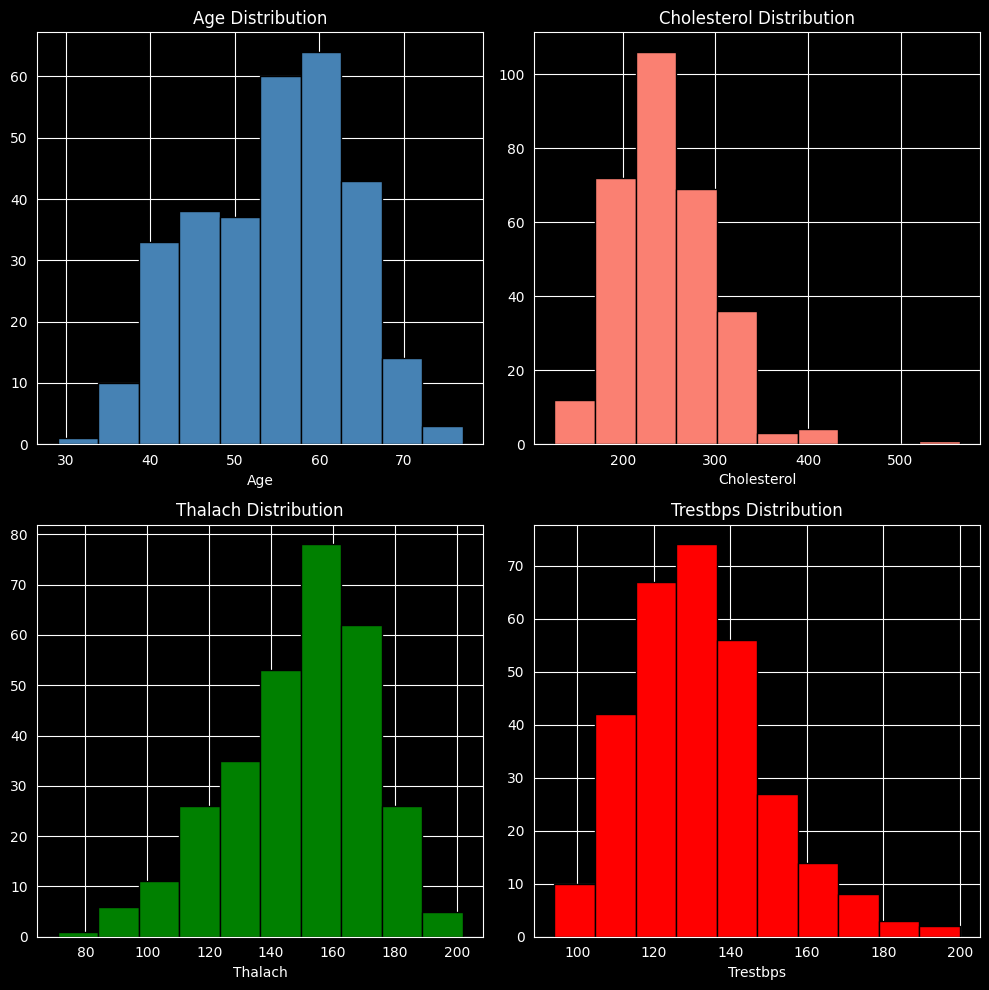

In [21]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))

df['age'].hist(ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

df['chol'].hist(ax=axes[0,1], color='salmon', edgecolor='black')
axes[0,1].set_title('Cholesterol Distribution')
axes[0,1].set_xlabel('Cholesterol')

df['thalach'].hist(ax=axes[1,0], color='green', edgecolor='black')
axes[1,0].set_title('Thalach Distribution')
axes[1,0].set_xlabel('Thalach')

df['trestbps'].hist(ax=axes[1,1], color='red', edgecolor='black')
axes[1,1].set_title('Trestbps Distribution')
axes[1,1].set_xlabel('Trestbps')

plt.tight_layout()
plt.savefig('../Graphs/histograms.png', dpi=300, bbox_inches='tight')
plt.show()

 ## Outlier detection Using Z-Score

#### Z-Score measure how far a value is from the mean in terms of standard deviation

Formula:
z = (value - mean) / std

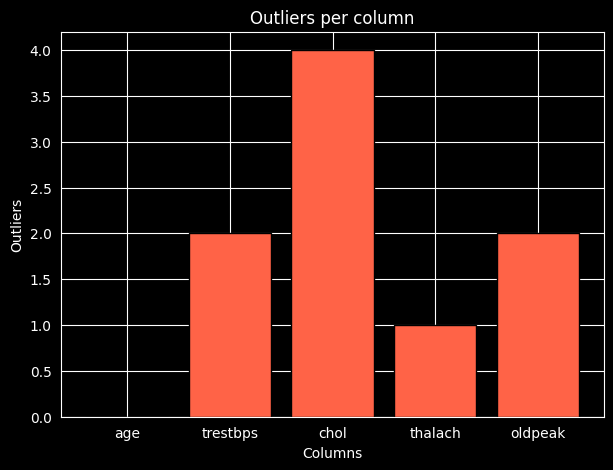

In [27]:
# calculate z-score for numerical columns
numerical_cols = ['age', 'trestbps', 'chol','thalach','oldpeak']
z_scores = np.abs(stats.zscore(df[numerical_cols].values))

outlier_counts = (z_scores > 3).sum(axis=0)
outlier_counts = pd.Series(outlier_counts, index=numerical_cols)

print('Outliers per column (z > 3): ', outliers_count)

plt.figure(figsize=(7,5))
plt.bar(outlier_counts.index, outlier_counts.values, color='tomato', edgecolor='black')
plt.title('Outliers per column')
plt.xlabel('Columns')
plt.ylabel('Outliers')
plt.savefig('../Graphs/outliers.png', dpi=300, bbox_inches='tight')
plt.show()


## Correlation Heatmap

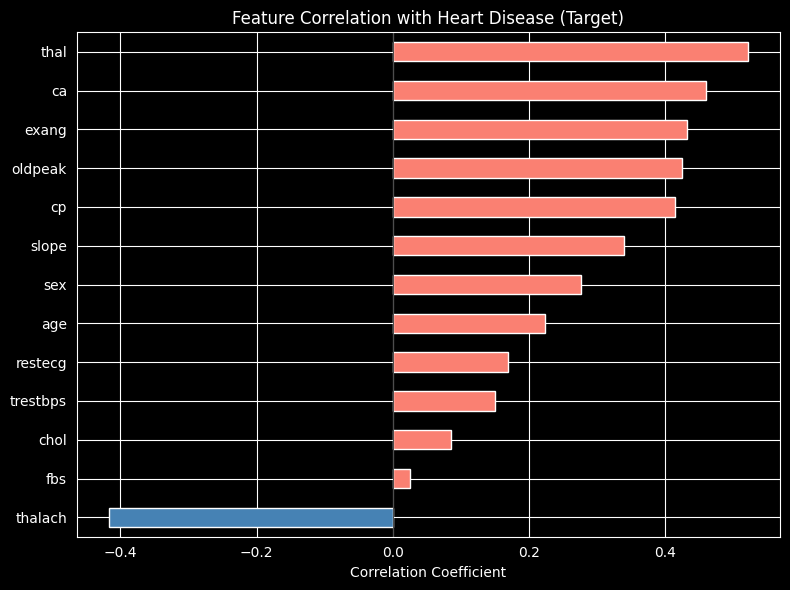

In [32]:
target_corr = df.corr()['target'].drop('target').sort_values()

plt.figure(figsize=(8, 6))
target_corr.plot(kind='barh',
                color=['salmon' if x > 0 else 'steelblue' for x in target_corr])
plt.title('Feature Correlation with Heart Disease (Target)')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../Graphs/correlation_target.png', dpi=300, bbox_inches='tight')
plt.show()

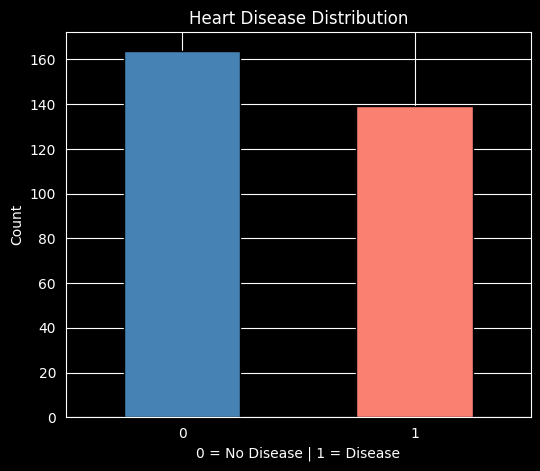

In [34]:
plt.figure(figsize=(6, 5))
df['target'].value_counts().plot(kind='bar', color=['steelblue','salmon'], edgecolor='black')
plt.title('Heart Disease Distribution')
plt.xlabel('0 = No Disease | 1 = Disease')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig('../Graphs/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# ---- Target Distribution ----

plt.figure(figsize=(6, 5))
df['target'].value_counts().plot(kind='bar',
                                  color=['steelblue','salmon'],
                                  edgecolor='black')
plt.title('Heart Disease Distribution')
plt.xlabel('0 = No Disease | 1 = Disease')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig('../Graphs/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print exact numbers
print(df['target'].value_counts())
print(f"\nNo Disease: {(df['target']==0).sum()} patients ({(df['target']==0).mean()*100:.1f}%)")
print(f"Has Disease: {(df['target']==1).sum()} patients ({(df['target']==1).mean()*100:.1f}%)")

target
0    164
1    139
Name: count, dtype: int64

No Disease: 164 patients (54.1%)
Has Disease: 139 patients (45.9%)


## Hypothesis Testing


In [41]:
no_disease = df[df['target']== 0]
has_disease = df[df['target']== 1]

# Test Cholesterol
t_stat, probability_value = stats.ttest_ind(no_disease['chol'], has_disease['chol'])
print('T-Test Cholesterol')
print(f"No Disease Mean: {no_disease['chol'].mean():.2f}")
print(f"has Disease Mean: {has_disease['chol'].mean():.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"Probability Value: {probability_value:.4f}")
print("Significant!" if probability_value < 0.05 else "Not significant!")

print(f"---"*20)

# Test Max Heart Rate (Thalch)
t_stat2, probability_value2 = stats.ttest_ind(no_disease['thalach'], has_disease['thalach'])
print('T-Test Max Heart Rate (thalach)')
print(f"No Disease Mean: {no_disease['thalach'].mean():.2f}")
print(f"has Disease Mean: {has_disease['thalach'].mean():.2f}")
print(f"T-Statistic: {t_stat2:.4f}")
print(f"Probability Value: {probability_value2:.4f}")
print("Significant!" if probability_value2 < 0.05 else "Not significant!")

T-Test Cholesterol
No Disease Mean: 242.64
has Disease Mean: 251.47
T-Statistic: -1.4829
Probability Value: 0.1391
Not significant!
------------------------------------------------------------
T-Test Max Heart Rate (thalach)
No Disease Mean: 158.38
has Disease Mean: 139.26
T-Statistic: 7.9636
Probability Value: 0.0000
Significant!


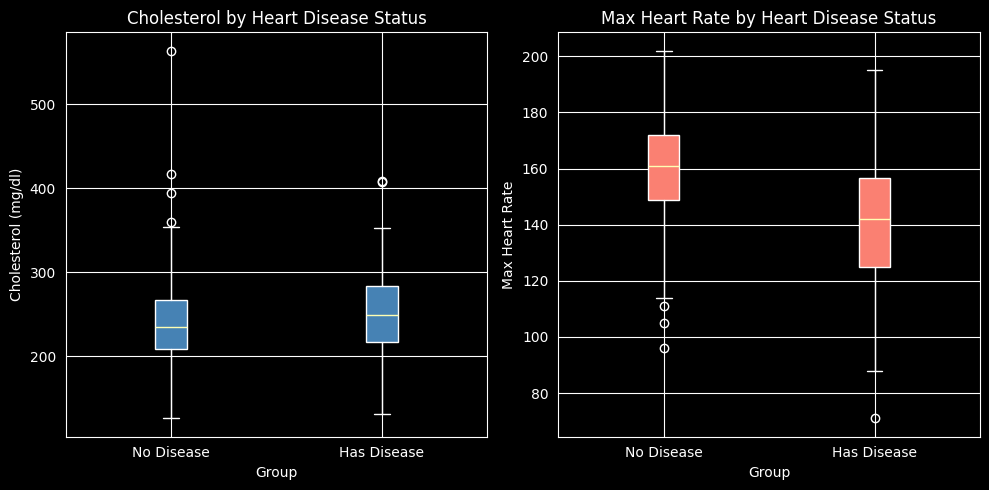

In [48]:
# Tests Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Cholesterol
axes[0].boxplot([no_disease['chol'], has_disease['chol']],
                labels=['No Disease', 'Has Disease'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue'))
axes[0].set_title('Cholesterol by Heart Disease Status')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Cholesterol (mg/dl)')

# Max Heart Rate
axes[1].boxplot([no_disease['thalach'], has_disease['thalach']],
                labels=['No Disease', 'Has Disease'],
                patch_artist=True,
                boxprops=dict(facecolor='salmon'))
axes[1].set_title('Max Heart Rate by Heart Disease Status')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Max Heart Rate')


plt.tight_layout()
plt.savefig('../Graphs/boxplots.png', dpi=300, bbox_inches='tight')
plt.show()